# 📊 Data Analyst Portfolio Project: Walmart Sales Forecasting

## Objective
Analyze real-world retail data to uncover trends and build predictive models for weekly sales.

## Skills Demonstrated
- Data Cleaning & Merging Multiple Tables
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Model Evaluation & Comparison
- Business Insights

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline

## Step 1: Load and Merge Data

In [2]:
train = pd.read_csv('train.csv', parse_dates=['Date'])
features = pd.read_csv('features.csv', parse_dates=['Date'])
stores = pd.read_csv('stores.csv')

df = train.merge(features, on=['Store','Date'], how='left')
df = df.merge(stores, on='Store', how='left')

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


## Step 2: Data Cleaning

In [3]:
df = df.fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     421570 non-null  float64       
 8   MarkDown2     421570 non-null  float64       
 9   MarkDown3     421570 non-null  float64       
 10  MarkDown4     421570 non-null  float64       
 11  MarkDown5     421570 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  IsHoliday_y   421570 non-null  bool          
 15  Type          421

## Step 3: Feature Engineering

In [4]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week.astype(int)

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size,year,month,week
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False,A,151315,2010,2,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,True,A,151315,2010,2,6
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,False,A,151315,2010,2,7
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,False,A,151315,2010,2,8
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,False,A,151315,2010,3,9


## Step 4: Exploratory Data Analysis

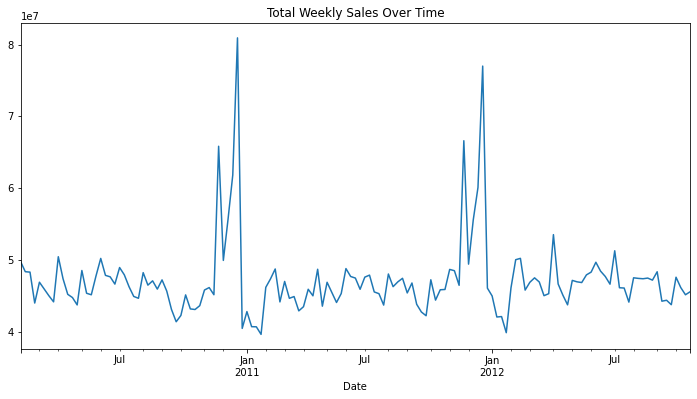

In [5]:
plt.figure(figsize=(12,6))
df.groupby('Date')['Weekly_Sales'].sum().plot()
plt.title('Total Weekly Sales Over Time')
plt.show()

## Step 5: Prepare Data for Modeling

In [6]:
features_cols = ['Store','Dept','year','month','week','Temperature','Fuel_Price','CPI','Unemployment']

X = df[features_cols]
y = df['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

## Step 6: Train Models

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, random_state=42)

## Step 7: Evaluate Models

In [9]:
lr_preds = lr.predict(X_test)
rf_preds = rf.predict(X_test)

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f'{name} MAE: {mae:.2f}')
    print(f'{name} RMSE: {rmse:.2f}\n')

evaluate(y_test, lr_preds, 'Linear Regression')
evaluate(y_test, rf_preds, 'Random Forest')

Linear Regression MAE: 12863.32
Linear Regression RMSE: 18659.66

Random Forest MAE: 9100.08
Random Forest RMSE: 14257.98



## Step 8: Visualization

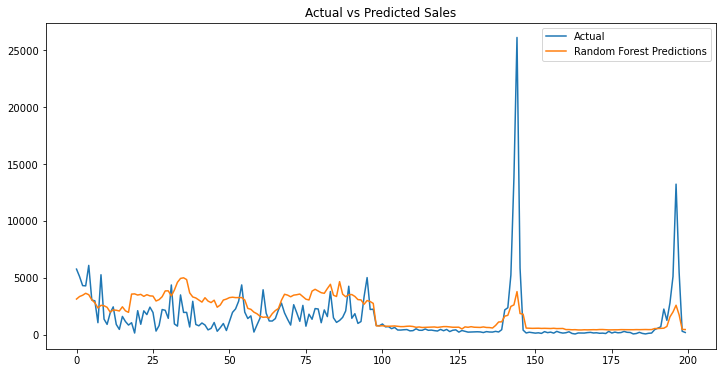

In [10]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(rf_preds[:200], label='Random Forest Predictions')
plt.legend()
plt.title('Actual vs Predicted Sales')
plt.show()

## Step 9: Feature Importance

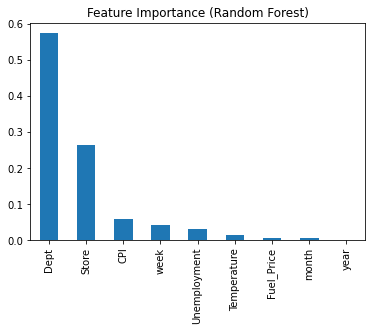

In [11]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features_cols).sort_values(ascending=False)

feat_imp.plot(kind='bar')
plt.title('Feature Importance (Random Forest)')
plt.show()

## Business Insights
- Seasonal trends significantly impact weekly sales.
- Economic indicators (CPI, unemployment) show measurable influence.
- Certain stores and departments consistently outperform others.

## Next Steps
- Add time-series specific models (ARIMA/Prophet)
- Perform hyperparameter tuning
- Incorporate holiday effects more deeply